# Lista de Exercícios 01 — Prática com PyTorch

**Disciplina:** Inteligência Artificial  
**Prof. Gabriel Duarte**  
**Aluna:** Alane Damasceno Moreno  

## Métodos baseados em distância: k-NN, k-Means e DBSCAN

Neste notebook implementei, do zero e utilizando PyTorch, os três métodos baseados em distância solicitados na atividade: **k-NN**, **k-Means** e **DBSCAN**.

Utilizei a base pública **Iris**, trabalhando apenas com as duas características da pétala para facilitar a visualização dos resultados em duas dimensões.

Além das implementações, também incluí os desafios pedidos na lista:
- região de decisão do k-NN;
- curva de inércia do k-Means;
- método do cotovelo;
- acurácia não supervisionada do k-Means;
- análise da sensibilidade do DBSCAN ao parâmetro `eps`;
- comparação final entre as três técnicas.

## 1. Preparação do ambiente

Primeiro instalo as bibliotecas necessárias para executar a atividade no Google Colab.

In [ ]:
!pip install torch scikit-learn matplotlib pandas -q

Agora importo as bibliotecas que serão utilizadas ao longo do notebook e defino a semente aleatória para tornar os resultados reproduzíveis.

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Versão do PyTorch:", torch.__version__)
print("GPU disponível:", torch.cuda.is_available())
print("Dispositivo usado:", device)

Versão do PyTorch: 2.11.0+cpu
GPU disponível: False
Dispositivo usado: cpu


## 2. Carregamento da base Iris

A base Iris possui 150 amostras, 4 atributos numéricos e 3 espécies de flores: setosa, versicolor e virginica.

In [ ]:
iris = load_iris()

X = iris.data
y = iris.target
nomes = iris.target_names

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)
print("Espécies:", nomes)

df = pd.DataFrame(X, columns=iris.feature_names)
df["classe"] = y
df["especie"] = [nomes[i] for i in y]

display(df.head())

Formato de X: (150, 4)
Formato de y: (150,)
Espécies: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),classe,especie
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 3. Pré-processamento obrigatório

Como os métodos desta atividade são baseados em distância, é importante que as características estejam na mesma escala.

Por isso, selecionei somente as características de **comprimento e largura da pétala** e apliquei a padronização z-score.

In [ ]:
X2 = X[:, 2:4]

media = X2.mean(axis=0)
desvio = X2.std(axis=0)

X2 = (X2 - media) / desvio

X2_t = torch.tensor(X2, dtype=torch.float32, device=device)
y_t = torch.tensor(y, dtype=torch.long, device=device)

print("Formato dos dados em 2D:", X2_t.shape)
print("Média após padronização:", X2.mean(axis=0))
print("Desvio após padronização:", X2.std(axis=0))

Formato dos dados em 2D: torch.Size([150, 2])
Média após padronização: [-1.69864123e-15 -1.40924309e-15]
Desvio após padronização: [1. 1.]


Antes de aplicar os algoritmos, visualizei a distribuição real das três espécies considerando somente os atributos da pétala.

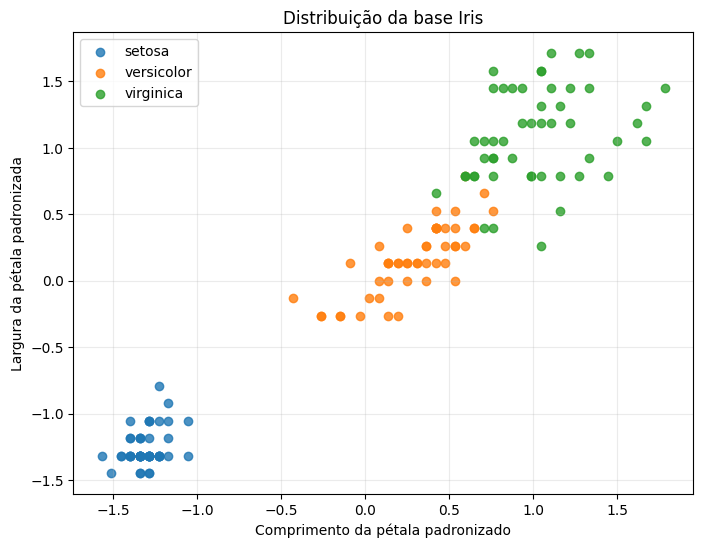

In [ ]:
plt.figure(figsize=(8, 6))

for classe, nome in enumerate(nomes):
    mascara = y == classe
    plt.scatter(
        X2[mascara, 0],
        X2[mascara, 1],
        label=nome,
        alpha=0.8
    )

plt.xlabel("Comprimento da pétala padronizado")
plt.ylabel("Largura da pétala padronizada")
plt.title("Distribuição da base Iris")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# Exercício 1 — k-NN com PyTorch

O k-NN é um método supervisionado. Para classificar um ponto novo, calculo a distância dele até os pontos de treino, seleciono os `k` vizinhos mais próximos e escolho a classe que aparece com maior frequência entre esses vizinhos.

## 1.1 Divisão entre treino e teste

Separei 80% das amostras para treino e 20% para teste. Usei `torch.manual_seed(42)` antes do embaralhamento para garantir que a divisão possa ser reproduzida.

In [ ]:
torch.manual_seed(42)

n = X2_t.shape[0]
indices = torch.randperm(n, device=device)

n_treino = int(0.8 * n)

indices_treino = indices[:n_treino]
indices_teste = indices[n_treino:]

X_treino = X2_t[indices_treino]
y_treino = y_t[indices_treino]

X_teste = X2_t[indices_teste]
y_teste = y_t[indices_teste]

print("Amostras de treino:", X_treino.shape[0])
print("Amostras de teste:", X_teste.shape[0])

Amostras de treino: 120
Amostras de teste: 30


## 1.2 Cálculo das distâncias

Implementei uma função utilizando `torch.cdist` para obter a matriz de distâncias euclidianas entre os pontos de teste e os pontos de treino.

In [ ]:
def calcular_distancias(X_treino, X_consulta):
    return torch.cdist(X_consulta, X_treino, p=2)

distancias = calcular_distancias(X_treino, X_teste)

print("Formato da matriz de distâncias:", distancias.shape)

Formato da matriz de distâncias: torch.Size([30, 120])


A matriz deve possuir 30 linhas, correspondentes às amostras de teste, e 120 colunas, correspondentes às amostras de treino.

## 1.3 Classificação com k-NN

Na função abaixo, uso `torch.topk` para localizar os vizinhos de menor distância. Em seguida, recupero os rótulos desses vizinhos e uso `torch.mode` para escolher a classe mais frequente.

In [ ]:
def knn_prever(X_treino, y_treino, X_consulta, k=5):
    distancias = torch.cdist(X_consulta, X_treino, p=2)

    _, indices_vizinhos = torch.topk(
        distancias,
        k=k,
        dim=1,
        largest=False
    )

    rotulos_vizinhos = y_treino[indices_vizinhos]

    previsoes = torch.mode(
        rotulos_vizinhos,
        dim=1
    ).values

    return previsoes

## 1.4 Acurácia para k = 5

Calculo a acurácia comparando cada previsão com o rótulo verdadeiro do conjunto de teste.

In [ ]:
def calcular_acuracia(y_real, y_previsto):
    return (y_real == y_previsto).float().mean().item()

previsoes_k5 = knn_prever(
    X_treino,
    y_treino,
    X_teste,
    k=5
)

acuracia_k5 = calcular_acuracia(
    y_teste,
    previsoes_k5
)

print(f"Acurácia com k = 5: {acuracia_k5:.4f}")
print(f"Acurácia percentual: {acuracia_k5 * 100:.2f}%")

Acurácia com k = 5: 0.9333
Acurácia percentual: 93.33%


### Resposta

A acurácia obtida acima mostra a proporção de amostras do conjunto de teste que foram classificadas corretamente. Como a atividade trabalha apenas com comprimento e largura da pétala, ainda assim é possível obter uma separação bastante boa entre as espécies.

## 1.5 Comparação entre diferentes valores de k

Agora executo o mesmo classificador para `k = 1, 3, 5, 7 e 9` e comparo as acurácias.

In [ ]:
valores_k = [1, 3, 5, 7, 9]
resultados_knn = []

for k in valores_k:
    previsoes = knn_prever(
        X_treino,
        y_treino,
        X_teste,
        k=k
    )

    acuracia = calcular_acuracia(
        y_teste,
        previsoes
    )

    resultados_knn.append({
        "k": k,
        "Acurácia": acuracia,
        "Acurácia (%)": acuracia * 100
    })

tabela_knn = pd.DataFrame(resultados_knn)
display(tabela_knn)

melhor_indice = tabela_knn["Acurácia"].idxmax()
melhor_k = int(tabela_knn.loc[melhor_indice, "k"])
melhor_acuracia = float(tabela_knn.loc[melhor_indice, "Acurácia"])

print("Melhor valor de k:", melhor_k)
print(f"Melhor acurácia: {melhor_acuracia * 100:.2f}%")

,k,Acurácia,Acurácia (%)
0,1,0.900000,89.999998
1,3,0.933333,93.333334
2,5,0.933333,93.333334
3,7,0.933333,93.333334
4,9,0.933333,93.333334


Melhor valor de k: 3
Melhor acurácia: 93.33%


### Resposta — Qual k deu o melhor resultado?

O melhor valor de `k` é mostrado automaticamente pela célula acima, com base na maior acurácia obtida no conjunto de teste.

Essa comparação também mostra que a escolha de `k` influencia diretamente o comportamento do classificador. Valores muito pequenos podem deixar o modelo mais sensível a pontos individuais, enquanto valores maiores tornam a decisão mais suavizada.

## 1.6 Desafio — região de decisão

Para visualizar melhor como o k-NN separa as três espécies, criei uma grade de pontos em duas dimensões e classifiquei cada posição dessa grade usando o melhor `k` encontrado anteriormente.

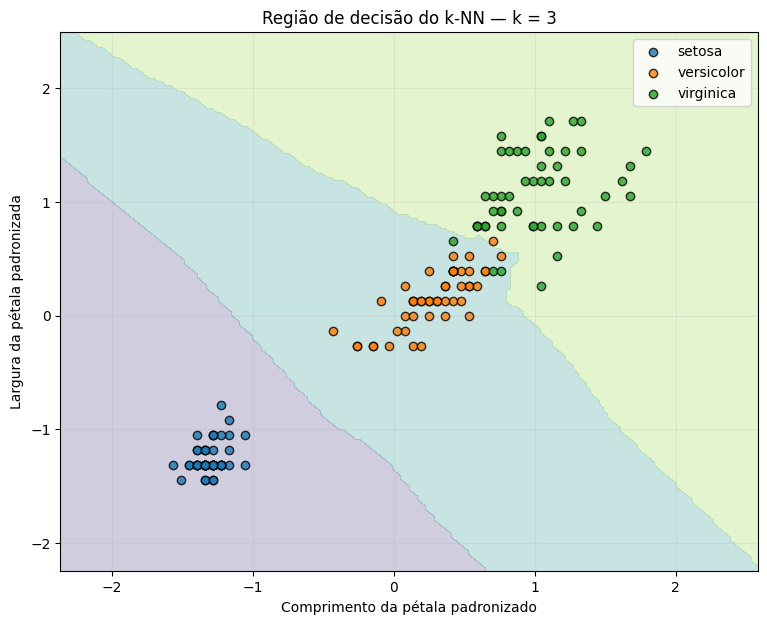

In [ ]:
def plotar_regiao_knn(X_treino, y_treino, X_total, y_total, k):
    X_np = X_total.detach().cpu().numpy()
    y_np = y_total.detach().cpu().numpy()

    x_min = X_np[:, 0].min() - 0.8
    x_max = X_np[:, 0].max() + 0.8
    y_min = X_np[:, 1].min() - 0.8
    y_max = X_np[:, 1].max() + 0.8

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.03),
        np.arange(y_min, y_max, 0.03)
    )

    grade = np.c_[xx.ravel(), yy.ravel()]

    grade_t = torch.tensor(
        grade,
        dtype=torch.float32,
        device=device
    )

    previsoes_grade = knn_prever(
        X_treino,
        y_treino,
        grade_t,
        k=k
    )

    Z = previsoes_grade.detach().cpu().numpy()
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(9, 7))

    plt.contourf(
        xx,
        yy,
        Z,
        alpha=0.25,
        levels=[-0.5, 0.5, 1.5, 2.5]
    )

    for classe, nome in enumerate(nomes):
        mascara = y_np == classe
        plt.scatter(
            X_np[mascara, 0],
            X_np[mascara, 1],
            label=nome,
            edgecolors="black",
            alpha=0.8
        )

    plt.xlabel("Comprimento da pétala padronizado")
    plt.ylabel("Largura da pétala padronizada")
    plt.title(f"Região de decisão do k-NN — k = {k}")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

plotar_regiao_knn(
    X_treino,
    y_treino,
    X2_t,
    y_t,
    melhor_k
)

### Análise da região de decisão

Observando o gráfico, percebo que a **setosa** forma uma região bastante bem separada das demais. Já **versicolor** e **virginica** possuem pontos mais próximos entre si e, por isso, a fronteira entre essas duas espécies é menos simples.

Isso ajuda a explicar por que podem ocorrer alguns erros de classificação justamente entre essas duas classes.

# Exercício 2 — k-Means com PyTorch

O k-Means é um método não supervisionado. Diferentemente do k-NN, ele não utiliza os rótulos das espécies durante o agrupamento.

O algoritmo funciona repetindo dois passos:
1. atribuir cada ponto ao centroide mais próximo;
2. recalcular cada centroide como a média dos pontos associados ao grupo.

## 2.1 Implementação do k-Means

In [ ]:
def kmeans_pytorch(
    X,
    k=3,
    max_iter=100,
    tolerancia=1e-4,
    seed=42
):
    gerador = torch.Generator(device=X.device)
    gerador.manual_seed(seed)

    indices_iniciais = torch.randperm(
        X.shape[0],
        generator=gerador,
        device=X.device
    )[:k]

    centroides = X[indices_iniciais].clone()

    historico_inercia = []

    for iteracao in range(max_iter):

        # Passo 1: atribuição
        distancias = torch.cdist(X, centroides, p=2)
        grupos = torch.argmin(distancias, dim=1)

        # Passo 2: atualização dos centroides
        novos_centroides = []

        for grupo in range(k):
            pontos = X[grupos == grupo]

            if pontos.shape[0] > 0:
                novo_centroide = pontos.mean(dim=0)
            else:
                novo_centroide = centroides[grupo]

            novos_centroides.append(novo_centroide)

        novos_centroides = torch.stack(novos_centroides)

        # Inércia
        novas_distancias = torch.cdist(
            X,
            novos_centroides,
            p=2
        )

        menores_distancias = novas_distancias.min(dim=1).values
        inercia = (menores_distancias ** 2).sum().item()
        historico_inercia.append(inercia)

        # Convergência
        diferenca = torch.norm(
            novos_centroides - centroides
        ).item()

        centroides = novos_centroides

        if diferenca < tolerancia:
            break

    distancias_finais = torch.cdist(
        X,
        centroides,
        p=2
    )

    grupos = torch.argmin(
        distancias_finais,
        dim=1
    )

    linhas = torch.arange(
        X.shape[0],
        device=X.device
    )

    inercia_final = (
        distancias_finais[linhas, grupos] ** 2
    ).sum().item()

    return (
        centroides,
        grupos,
        historico_inercia,
        iteracao + 1,
        inercia_final
    )

## 2.2 Execução com k = 3

Usei `k = 3` porque a base Iris possui três espécies. Entretanto, os rótulos das espécies não são utilizados durante o agrupamento.

In [ ]:
(
    centroides_k3,
    grupos_k3,
    historico_inercia,
    numero_iteracoes,
    inercia_final
) = kmeans_pytorch(
    X2_t,
    k=3,
    max_iter=100,
    tolerancia=1e-4,
    seed=42
)

print("Número de iterações:", numero_iteracoes)
print(f"Inércia final: {inercia_final:.4f}")
print("\nCentroides finais:")
print(centroides_k3)

Número de iterações: 11
Inércia final: 18.0270

Centroides finais:
tensor([[-1.3050, -1.2549],
        [ 1.0280,  1.1280],
        [ 0.3059,  0.1654]])


## 2.3 Visualização dos grupos encontrados

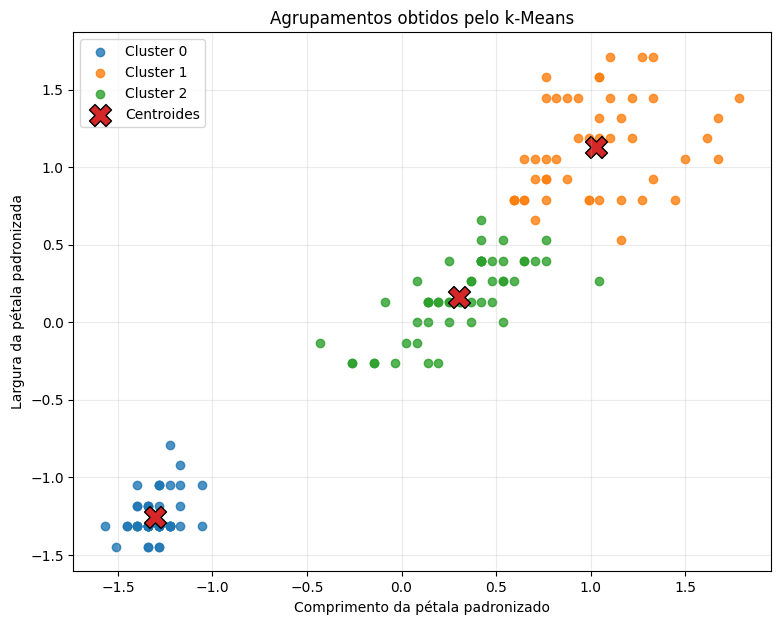

In [ ]:
X_np = X2_t.detach().cpu().numpy()
grupos_np = grupos_k3.detach().cpu().numpy()
centroides_np = centroides_k3.detach().cpu().numpy()

plt.figure(figsize=(9, 7))

for grupo in range(3):
    mascara = grupos_np == grupo

    plt.scatter(
        X_np[mascara, 0],
        X_np[mascara, 1],
        label=f"Cluster {grupo}",
        alpha=0.8
    )

plt.scatter(
    centroides_np[:, 0],
    centroides_np[:, 1],
    marker="X",
    s=250,
    edgecolors="black",
    label="Centroides"
)

plt.xlabel("Comprimento da pétala padronizado")
plt.ylabel("Largura da pétala padronizada")
plt.title("Agrupamentos obtidos pelo k-Means")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 2.4 Curva de inércia

A inércia corresponde à soma das distâncias ao quadrado entre cada ponto e o centroide do grupo ao qual ele foi atribuído.

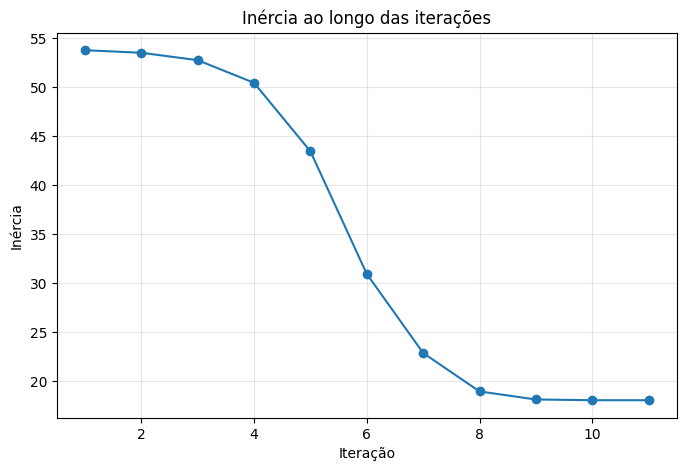

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(historico_inercia) + 1),
    historico_inercia,
    marker="o"
)

plt.xlabel("Iteração")
plt.ylabel("Inércia")
plt.title("Inércia ao longo das iterações")
plt.grid(alpha=0.3)
plt.show()

### Resposta — Para que lado a inércia deve caminhar?

A inércia deve **diminuir ao longo das iterações** até se estabilizar.

Isso acontece porque, em cada atualização, os centroides são reposicionados para representar melhor os pontos dos seus respectivos grupos. Quando os centroides praticamente deixam de mudar, o algoritmo atingiu a convergência e a inércia também tende a se estabilizar.

## 2.5 Desafio — método do cotovelo

Executei o k-Means para valores de `k` entre 1 e 5 e comparei as respectivas inércias finais.

,k,Inércia final
0,1,300.000000
1,2,54.168766
2,3,18.026951
3,4,17.320652
4,5,11.825465


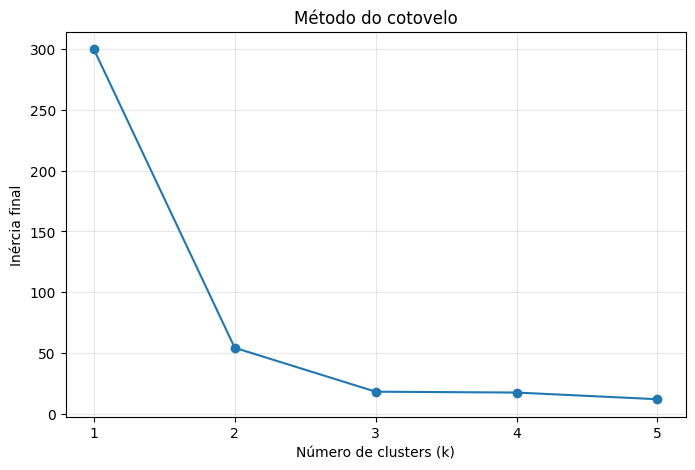

In [ ]:
valores_k_kmeans = [1, 2, 3, 4, 5]
inercias = []

for k in valores_k_kmeans:
    _, _, _, _, inercia_k = kmeans_pytorch(
        X2_t,
        k=k,
        max_iter=100,
        tolerancia=1e-4,
        seed=42
    )

    inercias.append(inercia_k)

tabela_cotovelo = pd.DataFrame({
    "k": valores_k_kmeans,
    "Inércia final": inercias
})

display(tabela_cotovelo)

plt.figure(figsize=(8, 5))
plt.plot(
    valores_k_kmeans,
    inercias,
    marker="o"
)

plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia final")
plt.title("Método do cotovelo")
plt.xticks(valores_k_kmeans)
plt.grid(alpha=0.3)
plt.show()

### Resposta — Por que k = 3 faz sentido para a Iris?

Pelo método do cotovelo, procuro um ponto em que aumentar o número de clusters deixa de produzir uma redução tão expressiva na inércia.

Além disso, neste conjunto de dados já sabemos que existem três espécies de Iris. Por isso, `k = 3` é uma escolha coerente para comparar os grupos encontrados pelo algoritmo com a estrutura conhecida da base.

Mesmo assim, o k-Means não recebe essa informação durante sua execução: ele utiliza somente a distância entre os pontos.

## 2.6 Desafio — acurácia não supervisionada

Como o número atribuído a cada cluster não corresponde diretamente ao número da espécie, associei cada cluster à classe real mais frequente dentro dele.

Essa associação é realizada somente depois do agrupamento, para avaliação.

In [ ]:
def converter_clusters_para_classes(
    grupos,
    y_real,
    k
):
    previsoes = torch.empty_like(y_real)
    associacoes = {}

    for cluster in range(k):
        mascara = grupos == cluster

        if mascara.sum() > 0:
            classe = torch.mode(
                y_real[mascara]
            ).values.item()

            associacoes[cluster] = classe
            previsoes[mascara] = classe

    return previsoes, associacoes


previsoes_kmeans, associacoes = converter_clusters_para_classes(
    grupos_k3,
    y_t,
    k=3
)

acuracia_kmeans = calcular_acuracia(
    y_t,
    previsoes_kmeans
)

print("Associação entre clusters e espécies:")

for cluster, classe in associacoes.items():
    print(
        f"Cluster {cluster} -> {nomes[classe]}"
    )

print(
    f"\nAcurácia ajustada do k-Means: "
    f"{acuracia_kmeans * 100:.2f}%"
)

print(
    f"Melhor acurácia do k-NN no conjunto de teste: "
    f"{melhor_acuracia * 100:.2f}%"
)

Associação entre clusters e espécies:
Cluster 0 -> setosa
Cluster 1 -> virginica
Cluster 2 -> versicolor

Acurácia ajustada do k-Means: 96.00%
Melhor acurácia do k-NN no conjunto de teste: 93.33%


### Comparação entre k-Means e k-NN

Os valores exibidos acima permitem comparar os resultados obtidos.

Entretanto, essa comparação precisa ser interpretada com cuidado. O **k-NN é supervisionado** e utiliza exemplos rotulados para classificar novas amostras. Já o **k-Means é não supervisionado** e forma os grupos somente pela proximidade entre os pontos.

Além disso, neste notebook o k-NN foi avaliado no conjunto de teste, enquanto a associação entre clusters e espécies do k-Means é feita sobre toda a base apenas para analisar o agrupamento.

# Exercício 3 — DBSCAN com PyTorch

O DBSCAN é um método de agrupamento baseado em densidade.

Diferentemente do k-Means, não é necessário informar previamente quantos grupos devem ser encontrados. O método utiliza principalmente dois parâmetros:

- `eps`: raio máximo da vizinhança;
- `min_pts`: quantidade mínima de pontos necessária para considerar uma região densa.

Os pontos podem ser classificados como:
- **núcleo**;
- **borda**;
- **ruído**.

## 3.1 Implementação do DBSCAN

Utilizei `torch.cdist` para criar a matriz de distâncias entre todos os pares de pontos e, a partir dela, construí a máscara de vizinhança.

In [ ]:
def dbscan_pytorch(
    X,
    eps=0.5,
    min_pts=8
):
    n = X.shape[0]

    # Matriz n x n com as distâncias
    matriz_distancias = torch.cdist(
        X,
        X,
        p=2
    )

    # Máscara indicando quais pontos estão dentro de eps
    vizinhanca = matriz_distancias <= eps

    # Quantidade de vizinhos de cada ponto
    quantidade_vizinhos = vizinhanca.sum(dim=1)

    # Pontos núcleo
    pontos_nucleo = quantidade_vizinhos >= min_pts

    # -99 = ainda não visitado
    # -1  = ruído
    labels = torch.full(
        (n,),
        -99,
        dtype=torch.long,
        device=X.device
    )

    cluster_atual = 0

    for i in range(n):

        if labels[i].item() != -99:
            continue

        if not pontos_nucleo[i].item():
            labels[i] = -1
            continue

        labels[i] = cluster_atual

        fila = [i]
        posicao = 0

        while posicao < len(fila):

            ponto = fila[posicao]
            posicao += 1

            if pontos_nucleo[ponto].item():

                vizinhos = torch.where(
                    vizinhanca[ponto]
                )[0].tolist()

                for vizinho in vizinhos:

                    estado = labels[vizinho].item()

                    if estado in (-99, -1):

                        if (
                            estado == -99
                            and pontos_nucleo[vizinho].item()
                        ):
                            fila.append(vizinho)

                        labels[vizinho] = cluster_atual

        cluster_atual += 1

    return (
        labels,
        pontos_nucleo,
        quantidade_vizinhos,
        matriz_distancias
    )

## 3.2 Execução com eps = 0.5 e min_pts = 8

In [ ]:
(
    labels_dbscan,
    nucleos_dbscan,
    qtd_vizinhos_dbscan,
    matriz_dbscan
) = dbscan_pytorch(
    X2_t,
    eps=0.5,
    min_pts=8
)

clusters = torch.unique(
    labels_dbscan[labels_dbscan >= 0]
)

quantidade_clusters = len(clusters)
quantidade_ruido = (labels_dbscan == -1).sum().item()

print("Formato da matriz de distâncias:", matriz_dbscan.shape)
print("Quantidade de grupos encontrados:", quantidade_clusters)
print("Quantidade de pontos de ruído:", quantidade_ruido)
print("Quantidade de pontos núcleo:", nucleos_dbscan.sum().item())

Formato da matriz de distâncias: torch.Size([150, 150])
Quantidade de grupos encontrados: 2
Quantidade de pontos de ruído: 0
Quantidade de pontos núcleo: 149


### Resposta

Com `eps = 0.5` e `min_pts = 8`, a célula acima mostra automaticamente quantos grupos foram encontrados e quantos pontos foram classificados como ruído na base Iris padronizada em duas dimensões.

## 3.3 Classificação dos pontos como núcleo, borda ou ruído

In [ ]:
tipos = []

for i in range(X2_t.shape[0]):

    if labels_dbscan[i].item() == -1:
        tipos.append("Ruído")

    elif nucleos_dbscan[i].item():
        tipos.append("Núcleo")

    else:
        tipos.append("Borda")

tabela_dbscan = pd.DataFrame({
    "Índice": np.arange(X2_t.shape[0]),
    "Cluster": labels_dbscan.detach().cpu().numpy(),
    "Tipo": tipos,
    "Número de vizinhos": qtd_vizinhos_dbscan.detach().cpu().numpy(),
    "Espécie real": [nomes[i] for i in y]
})

display(tabela_dbscan.head(20))

print("\nQuantidade por tipo:")
display(tabela_dbscan["Tipo"].value_counts())

,Índice,Cluster,Tipo,Número de vizinhos,Espécie real
0,0,0,Núcleo,49,setosa
1,1,0,Núcleo,49,setosa
2,2,0,Núcleo,49,setosa
3,3,0,Núcleo,49,setosa
4,4,0,Núcleo,49,setosa
5,5,0,Núcleo,49,setosa
6,6,0,Núcleo,50,setosa
7,7,0,Núcleo,49,setosa
8,8,0,Núcleo,49,setosa
9,9,0,Núcleo,48,setosa



Quantidade por tipo:


,count
Tipo,
Núcleo,149
Borda,1


## 3.4 Visualização dos clusters do DBSCAN

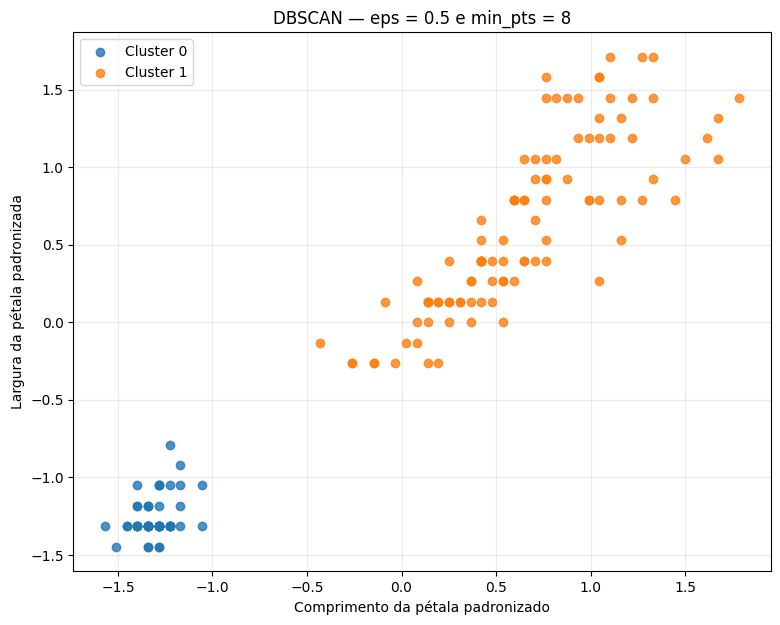

In [ ]:
def plotar_dbscan(X, labels, nucleos, titulo):
    X_np = X.detach().cpu().numpy()
    labels_np = labels.detach().cpu().numpy()
    nucleos_np = nucleos.detach().cpu().numpy()

    plt.figure(figsize=(9, 7))

    for cluster in sorted(np.unique(labels_np)):

        mascara = labels_np == cluster

        if cluster == -1:
            plt.scatter(
                X_np[mascara, 0],
                X_np[mascara, 1],
                marker="x",
                s=90,
                label="Ruído"
            )

        else:
            plt.scatter(
                X_np[mascara, 0],
                X_np[mascara, 1],
                label=f"Cluster {cluster}",
                alpha=0.8
            )

    plt.xlabel("Comprimento da pétala padronizado")
    plt.ylabel("Largura da pétala padronizada")
    plt.title(titulo)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


plotar_dbscan(
    X2_t,
    labels_dbscan,
    nucleos_dbscan,
    "DBSCAN — eps = 0.5 e min_pts = 8"
)

## 3.5 Desafio — sensibilidade ao valor de eps

Agora mantenho `min_pts = 8` e comparo os resultados para `eps = 0.2, 0.5, 0.8 e 1.0`.

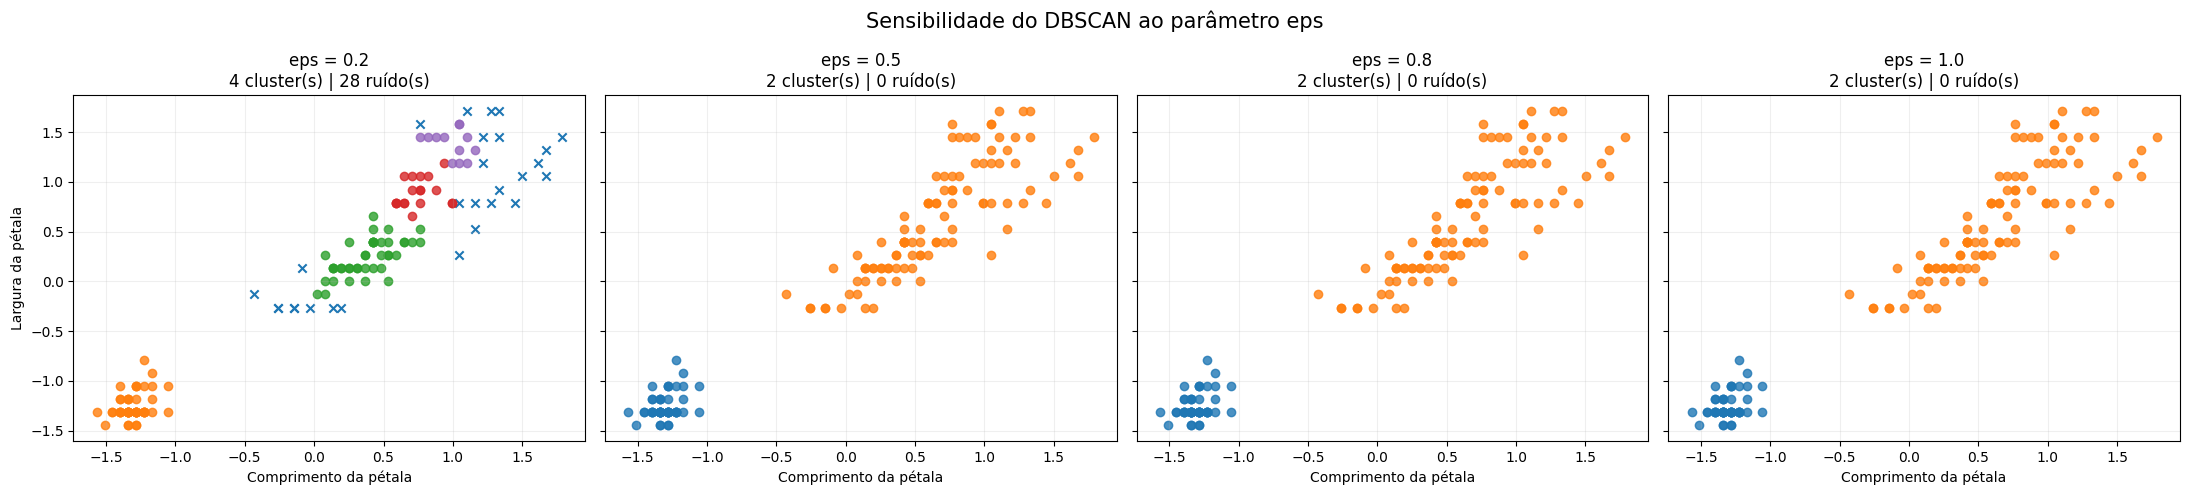

,eps,Clusters,Ruídos
0,0.2,4,28
1,0.5,2,0
2,0.8,2,0
3,1.0,2,0


In [ ]:
valores_eps = [0.2, 0.5, 0.8, 1.0]

fig, eixos = plt.subplots(
    1,
    4,
    figsize=(22, 5),
    sharex=True,
    sharey=True
)

resultados_eps = []

X_np = X2_t.detach().cpu().numpy()

for eixo, eps in zip(eixos, valores_eps):

    labels_eps, nucleos_eps, _, _ = dbscan_pytorch(
        X2_t,
        eps=eps,
        min_pts=8
    )

    labels_np = labels_eps.detach().cpu().numpy()

    numero_clusters = len(
        torch.unique(
            labels_eps[labels_eps >= 0]
        )
    )

    numero_ruidos = (
        labels_eps == -1
    ).sum().item()

    resultados_eps.append({
        "eps": eps,
        "Clusters": numero_clusters,
        "Ruídos": numero_ruidos
    })

    for cluster in sorted(np.unique(labels_np)):

        mascara = labels_np == cluster

        if cluster == -1:
            eixo.scatter(
                X_np[mascara, 0],
                X_np[mascara, 1],
                marker="x",
                label="Ruído"
            )

        else:
            eixo.scatter(
                X_np[mascara, 0],
                X_np[mascara, 1],
                label=f"Cluster {cluster}",
                alpha=0.8
            )

    eixo.set_title(
        f"eps = {eps}\n"
        f"{numero_clusters} cluster(s) | "
        f"{numero_ruidos} ruído(s)"
    )

    eixo.set_xlabel("Comprimento da pétala")
    eixo.grid(alpha=0.2)

eixos[0].set_ylabel("Largura da pétala")

plt.suptitle(
    "Sensibilidade do DBSCAN ao parâmetro eps",
    fontsize=15
)

plt.tight_layout()
plt.show()

display(pd.DataFrame(resultados_eps))

### Resposta — O que acontece quando eps muda?

Quando `eps` é muito baixo, cada ponto possui uma vizinhança pequena. Com isso, vários pontos podem não alcançar a densidade mínima exigida e acabam sendo classificados como ruído, além de poderem surgir grupos pequenos.

À medida que `eps` aumenta, mais pontos passam a ser considerados vizinhos e os grupos começam a se unir.

Quando `eps` fica muito alto, regiões diferentes podem acabar conectadas, fazendo com que uma grande parte da base seja considerada pertencente ao mesmo grupo.

Portanto, o parâmetro `eps` possui grande influência na estrutura encontrada pelo DBSCAN.

# 4. Comparação final das técnicas

In [ ]:
comparacao = pd.DataFrame({
    "Técnica": [
        "k-NN",
        "k-Means",
        "DBSCAN"
    ],

    "Aprendizado": [
        "Supervisionado",
        "Não supervisionado",
        "Não supervisionado"
    ],

    "Parâmetros principais": [
        f"k = {melhor_k}",
        "k = 3",
        "eps = 0.5 e min_pts = 8"
    ],

    "Resultado": [
        f"Melhor acurácia no teste = {melhor_acuracia * 100:.2f}%",
        f"Acurácia ajustada = {acuracia_kmeans * 100:.2f}%",
        f"{quantidade_clusters} cluster(s) e {quantidade_ruido} ruído(s)"
    ]
})

display(comparacao)

,Técnica,Aprendizado,Parâmetros principais,Resultado
0,k-NN,Supervisionado,k = 3,Melhor acurácia no teste = 93.33%
1,k-Means,Não supervisionado,k = 3,Acurácia ajustada = 96.00%
2,DBSCAN,Não supervisionado,eps = 0.5 e min_pts = 8,2 cluster(s) e 0 ruído(s)


## 4.1 Qual técnica deu melhor separação das três espécies na Iris?

Considerando o objetivo de identificar corretamente as três espécies, o **k-NN é o método mais adequado entre os três**, pois utiliza os rótulos conhecidos durante o aprendizado e realiza diretamente uma tarefa de classificação.

A região de decisão também mostra que ele consegue separar muito bem a setosa e construir uma fronteira entre versicolor e virginica, mesmo existindo alguma sobreposição entre essas duas espécies.

## 4.2 O k-Means superou o k-NN? Por quê?

Para responder numericamente, considero os valores exibidos na tabela anterior.

Mesmo que os valores possam ficar próximos em uma determinada execução, os métodos resolvem problemas diferentes. O k-NN utiliza exemplos com classes conhecidas, enquanto o k-Means tenta descobrir grupos apenas pela distância entre os pontos.

Além disso, a acurácia ajustada do k-Means foi calculada associando posteriormente cada cluster à espécie predominante. Essa associação não faz parte do treinamento do algoritmo.

Por isso, para uma situação em que existem rótulos e o objetivo é classificar espécies, considero o **k-NN mais apropriado**.

## 4.3 Quando faz mais sentido usar DBSCAN em vez de k-Means?

O DBSCAN faz mais sentido quando eu **não sei previamente quantos grupos existem**, quando os grupos podem possuir formatos irregulares ou quando existe interesse em identificar pontos isolados como ruído.

O k-Means, por outro lado, exige que o número de clusters seja informado e tende a funcionar melhor quando os grupos possuem uma organização mais compacta em torno dos centroides.

Uma característica interessante do DBSCAN nesta atividade é justamente a capacidade de separar pontos em **núcleo, borda e ruído**, algo que o k-Means não faz.

# 5. Conclusão

Nesta atividade consegui observar três maneiras diferentes de utilizar distância em Inteligência Artificial.

O **k-NN** utiliza a proximidade entre exemplos já classificados para decidir a classe de uma nova amostra.

O **k-Means** tenta descobrir grupos nos dados movimentando centroides até alcançar a convergência, sem utilizar os rótulos reais.

O **DBSCAN** procura regiões de maior densidade e consegue identificar pontos que não pertencem adequadamente a nenhum grupo como ruído.

Na base Iris, os atributos da pétala oferecem uma separação visual bastante clara para a espécie setosa. Já versicolor e virginica ficam mais próximas, o que interfere principalmente nos métodos de agrupamento não supervisionado.

Também percebi que os parâmetros dos algoritmos têm efeitos diferentes: no k-NN, a escolha de `k` modifica a vizinhança utilizada na classificação; no k-Means, `k` define diretamente o número de grupos; e no DBSCAN, `eps` e `min_pts` controlam a densidade necessária para formar os clusters.

# Checklist da atividade

- [x] Base pública Iris
- [x] Dados padronizados
- [x] Duas características da pétala
- [x] k-NN implementado com PyTorch
- [x] Divisão 80% treino e 20% teste
- [x] `torch.cdist`
- [x] `torch.topk`
- [x] Acurácia para vários valores de k
- [x] Região de decisão
- [x] k-Means implementado com PyTorch
- [x] Atualização dos centroides
- [x] Critério de convergência
- [x] Inércia
- [x] Método do cotovelo
- [x] Acurácia não supervisionada
- [x] DBSCAN implementado com PyTorch
- [x] Pontos núcleo, borda e ruído
- [x] Sensibilidade ao eps
- [x] Comparação final entre as três técnicas